# 01.4 — Phân nhóm dữ liệu IT

Mục tiêu: kiểm tra 4 nhóm lớn, technical tags và provenance nhãn từ Train/Validation. Câu hỏi: vì sao không dùng taxonomy chi tiết? Trả lời: Phase 02 chỉ cần mô tả coverage IT; group/tag là metadata theo rule, không phải nhãn ngữ nghĩa thủ công. Notebook không gán lại nhãn hoặc đọc IT Test.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'data/processed/it_en_vi').is_dir(): ROOT = ROOT.parent
parts = [pd.read_json(ROOT / f'data/processed/it_en_vi/{split}.jsonl', lines=True) for split in ('train', 'validation')]
data = pd.concat(parts, ignore_index=True)
data.shape

(152044, 11)

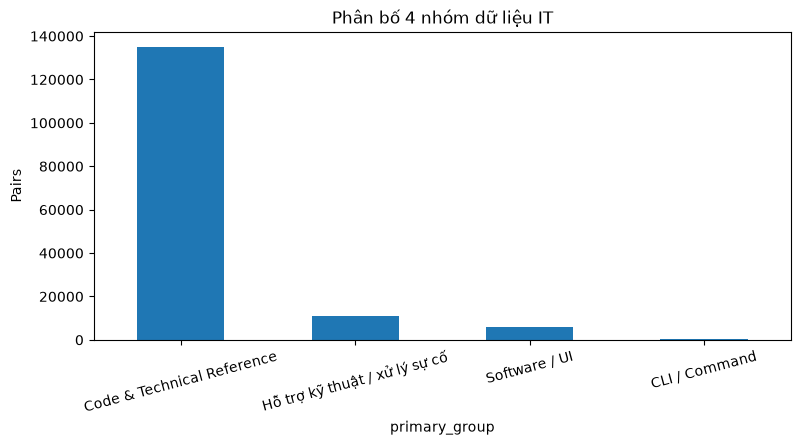

,primary_group,pairs
0,Code & Technical Reference,135199
1,Hỗ trợ kỹ thuật / xử lý sự cố,10873
2,Software / UI,5729
3,CLI / Command,243


In [2]:
group_counts = data.primary_group.value_counts().rename_axis('primary_group').reset_index(name='pairs')
ax = group_counts.plot.bar(x='primary_group', y='pairs', legend=False, figsize=(9, 4), rot=15, title='Phân bố 4 nhóm dữ liệu IT')
ax.set_ylabel('Pairs')
plt.show()
group_counts

In [3]:
data.group_method.value_counts().rename_axis('group_method').reset_index(name='pairs').assign(rate_percent=lambda x: (100 * x.pairs / len(data)).round(2))

,group_method,pairs,rate_percent
0,default_group,126523,83.21
1,rule_based,25521,16.79


In [4]:
samples_by_group = pd.concat([
    frame.sample(min(5, len(frame)), random_state=42)
    for _, frame in data.groupby('primary_group')
], ignore_index=True)[['primary_group', 'en_clean', 'vi_clean', 'technical_tags', 'group_method']]
samples_by_group

,primary_group,en_clean,vi_clean,technical_tags,group_method
0,CLI / Command,Best 9-Month CD Rates for October 2023 - CNET,Giá CD 9 tháng tốt nhất cho tháng 10 năm 2023 ...,[has_command],rule_based
1,CLI / Command,I spent hours debugging this tricky Python scr...,Tôi đã dành hàng giờ để gỡ lỗi đoạn script Pyt...,"[has_error, has_command, has_code_or_api]",rule_based
2,CLI / Command,Git is essential for collaborative software de...,Git là công cụ thiết yếu cho việc phát triển p...,[has_command],rule_based
3,CLI / Command,Apple Adds Last MacBook Pro With CD Drive to O...,Apple thêm MacBook Pro cuối cùng có ổ CD vào d...,"[has_error, has_command]",rule_based
4,CLI / Command,CD Player,Trình nghe CD,[has_command],rule_based
5,Code & Technical Reference,Amazon launches Fire HD 10 Kids and Fire HD 10...,Amazon ra mắt phiên bản máy tính bảng Fire HD ...,[has_version],rule_based
6,Code & Technical Reference,"Unknown view type ""%1""",Kiểu ô xem không rõ «% 1 ».,[],default_group
7,Code & Technical Reference,Twitch is testing a TikTok-style feed,Twitch đang thử nghiệm nguồn cấp dữ liệu kiểu ...,[],default_group
8,Code & Technical Reference,Cooler Master G2711 mini-LED gaming monitor un...,Màn hình chơi game mini LED Cooler Master G271...,[],default_group
9,Code & Technical Reference,File already exists,Tập tin đã có,[],default_group


In [5]:
method = 'rule_based'  # đổi sang default_group để review luồng còn lại
data.loc[data.group_method.eq(method), ['en_clean', 'vi_clean', 'primary_group', 'technical_tags']].sample(5, random_state=42)

,en_clean,vi_clean,primary_group,technical_tags
139721,"You cannot report this error, because the appl...",EMAIL OF TRANSLATORS,Hỗ trợ kỹ thuật / xử lý sự cố,[has_error]
10561,Create & HTML Slideshow...,Địa chỉ Email:,Code & Technical Reference,[has_code_or_api]
60832,Pimento turns creative briefs into visual mood...,Pimento biến các bản tóm tắt sáng tạo thành bả...,Hỗ trợ kỹ thuật / xử lý sự cố,[]
118243,One UI 5.1.1 finally rolling out to Galaxy Z F...,One UI 5.1.1 cuối cùng cũng được tung ra cho G...,Code & Technical Reference,[has_version]
150890,Secure lifetime access to CompTIA and IT study...,Bảo đảm quyền truy cập trọn đời vào hướng dẫn ...,Hỗ trợ kỹ thuật / xử lý sự cố,[]


## Technical tags

Tag là metadata phụ: một pair chỉ có một nhóm chính nhưng có thể có nhiều tag. Tag hỗ trợ đọc nội dung kỹ thuật và phân tích sau này; không được dùng làm điều kiện giữ hoặc loại pair.

In [6]:
tag_distribution = pd.read_csv(ROOT / 'data/final_report/it_en_vi/technical_tag_distribution.csv')
tag_distribution.assign(rate_percent=(100 * tag_distribution.pairs / len(data)).round(2))

,technical_tag,pairs,rate_percent
0,has_error,4513,2.97
1,has_command,243,0.16
2,has_ui,5740,3.78
3,has_code_or_api,1494,0.98
4,has_path,129,0.08
5,has_config,2179,1.43
6,has_version,7661,5.04


In [7]:
data.loc[data.technical_tags.map(len).gt(1), ['en_clean', 'vi_clean', 'primary_group', 'technical_tags']].sample(5, random_state=42)

,en_clean,vi_clean,primary_group,technical_tags
122995,We need to establish a clear ML workflow from ...,Chúng ta cần thiết lập một quy trình làm việc ...,Software / UI,"[has_ui, has_config]"
42828,Setting up a robust feature store can signific...,Thiết lập một feature store mạnh mẽ có thể tăn...,Software / UI,"[has_ui, has_config]"
44005,"4.5 million Hondas, Acuras are being recalled ...","4,5 triệu xe Honda, Acura bị thu hồi trên toàn...",Hỗ trợ kỹ thuật / xử lý sự cố,"[has_error, has_version]"
132435,Google Wallet is working on a confusing new Qu...,Google Wallet đang phát triển một tiện ích Qui...,Software / UI,"[has_ui, has_config]"
75178,Advanced users will appreciate the Konsole whi...,Người dùng Linux kinh nghiệm đánh giá cao Kons...,Software / UI,"[has_ui, has_config]"


Khi review, hỏi: nhóm lớn có đúng vai trò câu không, tag có được dùng như metadata thay vì một hệ phân nhóm khác không, và `group_method` có phản ánh đúng cách nhóm được gán hay không. Release này không dùng subcategory vì không có refinement nào có use case downstream riêng.